<div style="background-color: #84bfef; padding: 20px; border-radius: 10px">

# Desafío #1 | EDA RRHH
</div>


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Objetivo del análisis

Este EDA busca entender si el dataset de RRHH permite responder las preguntas del desafío, detectar problemas de calidad y preparar criterios para el análisis posterior y el dashboard.

El análisis contempla dos áreas:

- **Perfil y Desempeño Profesional:** perfil sociodemográfico y laboral de los empleados.
- **Absentismo y Bienestar Laboral:** magnitud, temporalidad y motivos del absentismo.

El EDA no limpia ni transforma definitivamente los datos. Solo identifica hallazgos, riesgos e incidencias que deberán tratarse en la fase de limpieza.


### 1.1 Preguntas de negocio, KPI y columnas

**Magnitud del absentismo**  
KPI / análisis: IDs con registros de ausencia y horas totales.  
Columnas: `ID`, `Absenteeism_hours`.

**Variación mensual del absentismo**  
KPI / análisis: mes pico por horas y por registros.  
Columnas: `Month_absence`, `Absenteeism_hours`, `ID`.

**Motivo principal de ausencia**  
KPI / análisis: motivo modal y motivos con más horas.  
Columnas: `Reason_absence`, `Absenteeism_hours`, `ID`.

**Continuidad operativa**  
KPI / análisis: carga laboral, hit target y horas de ausencia.  
Columnas: `Work_load_Average_day`, `Absenteeism_hours`, `Hit_target`.

**Perfil sociodemográfico/laboral**  
KPI / análisis: distribución por edad, educación, antigüedad y distancia.  
Columnas: `Age`, `Education`, `Service_time`, `Distance_Residence_Work`, `Son`, `Pet`.


## 2. Librerías


In [72]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 3. Carga de datos

El dataset se lee desde el archivo CSV versionado en el repositorio local:

`Data/raw/raw_data.csv`

Se usa ruta local del proyecto, no la URL de GitHub, para que el notebook funcione dentro de cualquier clon de la rama.


In [73]:
DATA_FILE = '../../Data/raw/raw_data_25052026.csv' # Cambio Pte nombre CSV
RRHH = pd.read_csv(DATA_FILE)

## 4. Vistazo inicial

Se revisa tamaño, columnas, tipos de datos y muestra inicial para entender cómo llega el dataset antes de analizarlo.


In [74]:
estructura_inicial = pd.DataFrame({
    "columna": RRHH.columns,
    "tipo_dato": RRHH.dtypes.astype(str).values,
    "nulos": RRHH.isna().sum().values,
    "vacios_texto": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ],
    "valores_unicos": RRHH.nunique().values
})

estructura_inicial


,columna,tipo_dato,nulos,vacios_texto,valores_unicos
0,ID,int64,0,0,36
1,Reason_absence,int64,0,0,28
2,Month_absence,int64,0,0,13
3,Day_week,int64,0,0,5
4,Seasons,int64,0,0,4
5,Transportation_expense,int64,0,0,24
6,Distance_Residence_Work,int64,0,0,25
7,Service_time,int64,0,0,18
8,Age,int64,0,0,22
9,Work_load_Average_day,object,0,0,38


In [75]:
RRHH.describe(include="all")


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740,...,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"222,196",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,NaN,...,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,NaN,...,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,NaN,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,NaN,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000


**Observación EDA:** `Work_load_Average_day` aparece como texto aunque representa una variable numérica. En esta fase se documenta el problema, pero la conversión definitiva corresponde a limpieza.


## 5. Unidad de análisis

El dataset contiene 740 filas y 36 IDs únicos. Esto indica que una fila no representa necesariamente un empleado único, sino un registro asociado a un empleado.

Como existen filas con `Absenteeism_hours = 0`, es más prudente hablar de **registro de seguimiento de RRHH** y no asumir que todas las filas son episodios reales de absentismo.<br> 
Cuando existe una medida disciplinaria `Absenteeism_hours = 0`.


In [76]:
unidad_analisis = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "Media de registros por ID",
        "Máximo de registros en un ID",
        "Registros con Absenteeism_hours = 0"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        round(RRHH.groupby("ID").size().mean(), 2),
        RRHH.groupby("ID").size().max(),
        (RRHH["Absenteeism_hours"] == 0).sum()
    ]
})

unidad_analisis


,Métrica,Resultado
0,Total registros,740.00
1,IDs únicos,36.00
2,Media de registros por ID,20.56
3,Máximo de registros en un ID,113.00
4,Registros con Absenteeism_hours = 0,44.00


## 6. Calidad inicial de datos

Se revisan nulos, vacíos, IDs repetidos, duplicados exactos y valores especiales. En esta fase no se corrige nada: solo se identifican incidencias para limpieza.


In [77]:
columnas_rrhh = RRHH.columns.tolist()

duplicados_exactos_por_fila = (
    RRHH
    .groupby(columnas_rrhh, dropna=False)
    .size()
    .reset_index(name="times_repeated")
    .query("times_repeated > 1")
)

ids_con_duplicados_exactos = (
    duplicados_exactos_por_fila["ID"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

control_calidad_registros = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "ID extras",
        "Duplicados exactos extra",
        "Filas involucradas en duplicados exactos",
        "Grupos exactos duplicados",
        "IDs con duplicados exactos"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        len(RRHH) - RRHH["ID"].nunique(),
        RRHH.duplicated(keep="first").sum(),
        RRHH.duplicated(keep=False).sum(),
        len(duplicados_exactos_por_fila),
        ids_con_duplicados_exactos.nunique()
    ],
    "Cómo se interpreta": [
        "Total de filas",
        "Empleados distintos",
        "Apariciones adicionales de IDs repetidos",
        "Filas repetidas completas sobrantes",
        "Originales + duplicadas",
        "Combinaciones de fila completa repetida",
        "IDs afectados por filas exactamente repetidas"
    ]
})

control_calidad_registros


,Métrica,Resultado,Cómo se interpreta
0,Total registros,740,Total de filas
1,IDs únicos,36,Empleados distintos
2,ID extras,704,Apariciones adicionales de IDs repetidos
3,Duplicados exactos extra,34,Filas repetidas completas sobrantes
4,Filas involucradas en duplicados exactos,60,Originales + duplicadas
5,Grupos exactos duplicados,26,Combinaciones de fila completa repetida
6,IDs con duplicados exactos,9,IDs afectados por filas exactamente repetidas


In [78]:
revision_nulos_vacios = pd.DataFrame({
    "columna": RRHH.columns,
    "nulos": RRHH.isna().sum().values,
    "vacios": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ]
})

revision_nulos_vacios["total_nulos_o_vacios"] = (
    revision_nulos_vacios["nulos"] + revision_nulos_vacios["vacios"]
)

revision_nulos_vacios


,columna,nulos,vacios,total_nulos_o_vacios
0,ID,0,0,0
1,Reason_absence,0,0,0
2,Month_absence,0,0,0
3,Day_week,0,0,0
4,Seasons,0,0,0
5,Transportation_expense,0,0,0
6,Distance_Residence_Work,0,0,0
7,Service_time,0,0,0
8,Age,0,0,0
9,Work_load_Average_day,0,0,0


**Observación EDA:** En esta etapa no concideramos nulos el valor 0 de los diferentes campos, habría que verificar en cada uno porque es boolean en algunos


In [79]:
codigos_a_documentar = ["Reason_absence", "Day_week", "Seasons", "Education"]

resumen_codigos = []
for columna in codigos_a_documentar:
    resumen_codigos.append({
        "variable": columna,
        "valores_distintos": RRHH[columna].nunique(),
        "valores_observados": sorted(RRHH[columna].dropna().unique().tolist())
    })

pd.DataFrame(resumen_codigos)


,variable,valores_distintos,valores_observados
0,Reason_absence,28,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Day_week,5,"[2, 3, 4, 5, 6]"
2,Seasons,4,"[1, 2, 3, 4]"
3,Education,4,"[1, 2, 3, 4]"


In [80]:
ids_con_perfil_variable = sorted(
    {
        id_empleado
        for ids in variacion_perfil_por_id["ids_que_varian"]
        for id_empleado in ids
    }
)

registros_perfil_variable = (
    RRHH[RRHH["ID"].isin(ids_con_perfil_variable)]
    .sort_values(["ID", "Month_absence", "Reason_absence", "Absenteeism_hours"])
)

print("IDs con cambios en variables de perfil:", ids_con_perfil_variable)
registros_perfil_variable


NameError: name 'variacion_perfil_por_id' is not defined

**Lectura EDA:** la mayoría de variables de perfil se mantienen constantes por empleado. Sin embargo, se detecta el `ID 29` con cambios en variables como edad, educación, distancia al trabajo, peso, altura y BMI. Esto puede indicar error de carga, reutilización de ID o mezcla de registros de personas distintas, y debe revisarse en limpieza.


## 7. Visualización variables

Se revisan distribuciones de variables fundamentales para entender rangos, concentración de valores y posibles valores extremos.


In [ ]:
variables_fundamentales = [
    "Age",
    "Service_time",
    "Distance_Residence_Work",
    "Transportation_expense",
    "Hit_target",
    "Body_mass_index",
    "Absenteeism_hours"
]

RRHH[variables_fundamentales].describe().round(2)


,Age,Service_time,Distance_Residence_Work,Transportation_expense,Hit_target,Body_mass_index,Absenteeism_hours
count,740.00,740.00,740.00,740.00,740.00,740.00,740.00
mean,36.45,12.55,29.63,221.33,94.59,26.68,6.92
std,6.48,4.38,14.84,66.95,3.78,4.29,13.33
min,27.00,1.00,5.00,118.00,81.00,19.00,0.00
25%,31.00,9.00,16.00,179.00,93.00,24.00,2.00
50%,37.00,13.00,26.00,225.00,95.00,25.00,3.00
75%,40.00,16.00,50.00,260.00,97.00,31.00,8.00
max,58.00,29.00,52.00,388.00,100.00,38.00,120.00


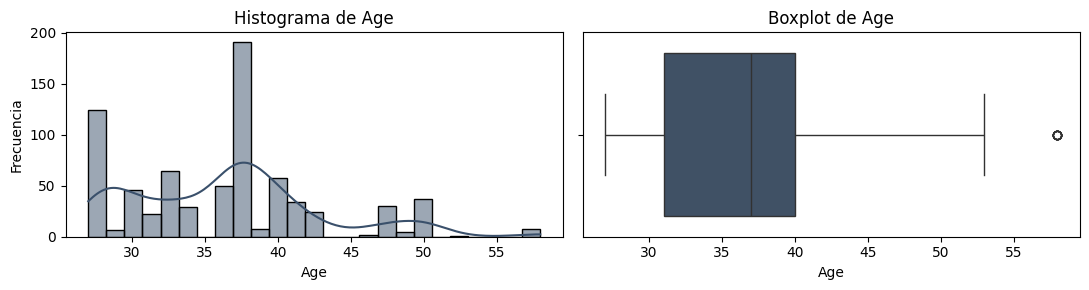

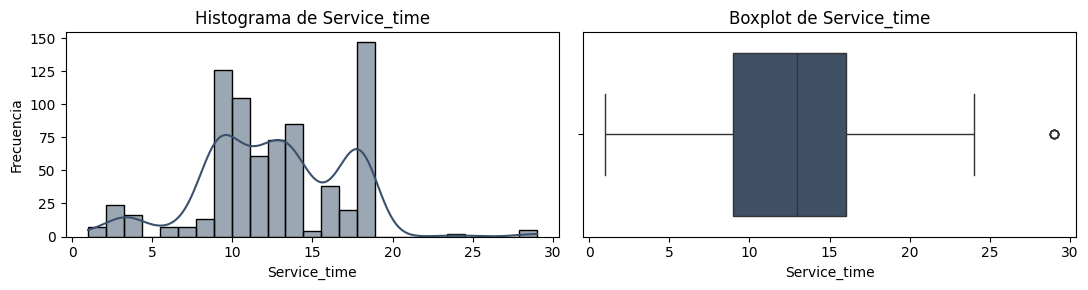

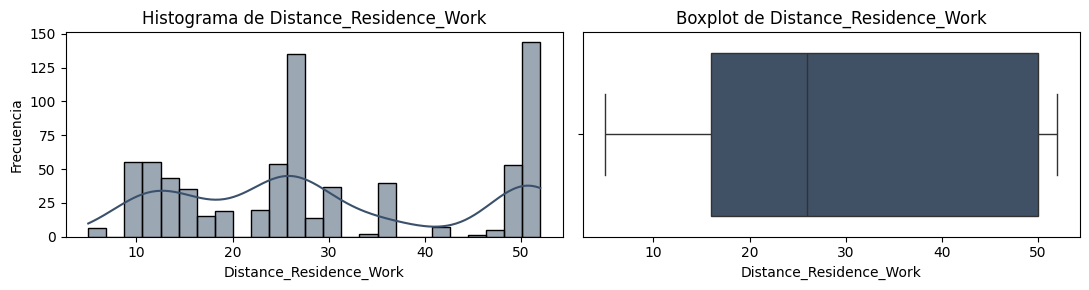

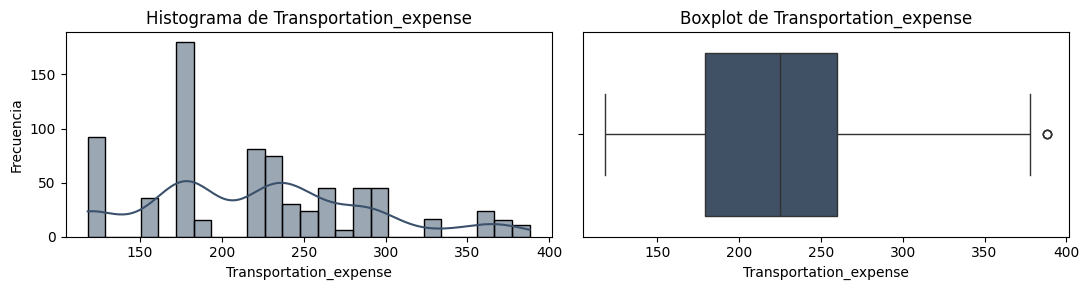

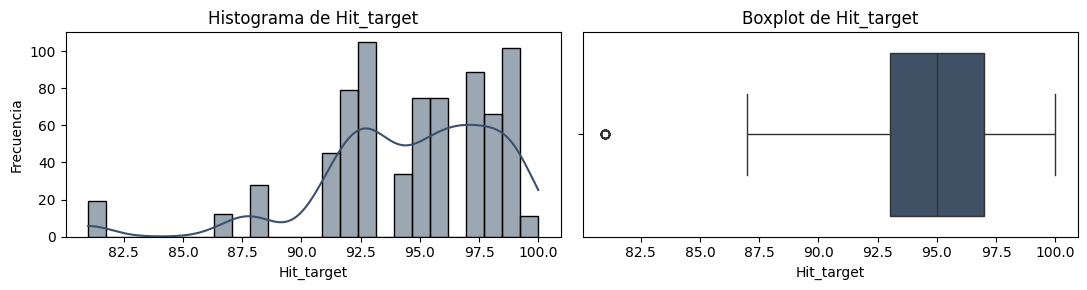

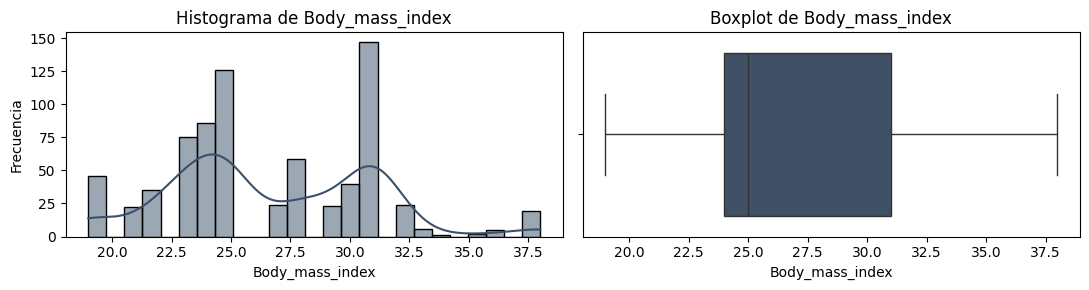

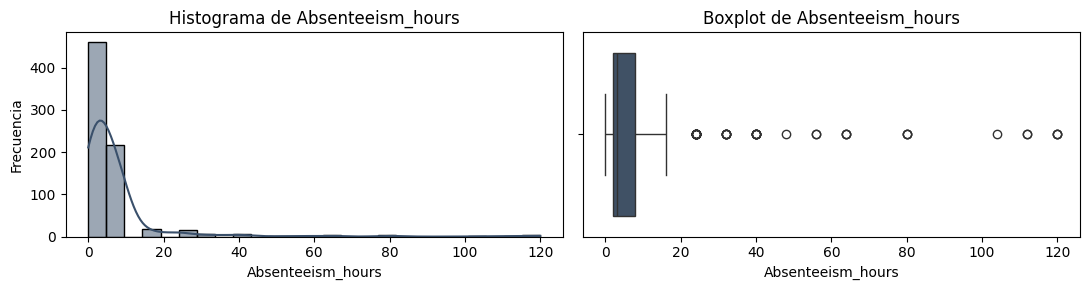

In [ ]:
color_principal = "#3A506B"

for variable in variables_fundamentales:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))

    sns.histplot(data=RRHH, x=variable, bins=25, kde=True, color=color_principal, ax=axes[0])
    axes[0].set_title(f"Histograma de {variable}")
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(data=RRHH, x=variable, color=color_principal, ax=axes[1])
    axes[1].set_title(f"Boxplot de {variable}")
    axes[1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()


## 8. Análisis relaciones clave

Se exploran relaciones directamente conectadas con las preguntas de negocio: absentismo por mes, motivo, día de la semana y perfil del empleado.


Pregunta negocio Perfil y Desempeño

### 8.1 Antigüedad vs Hit_target

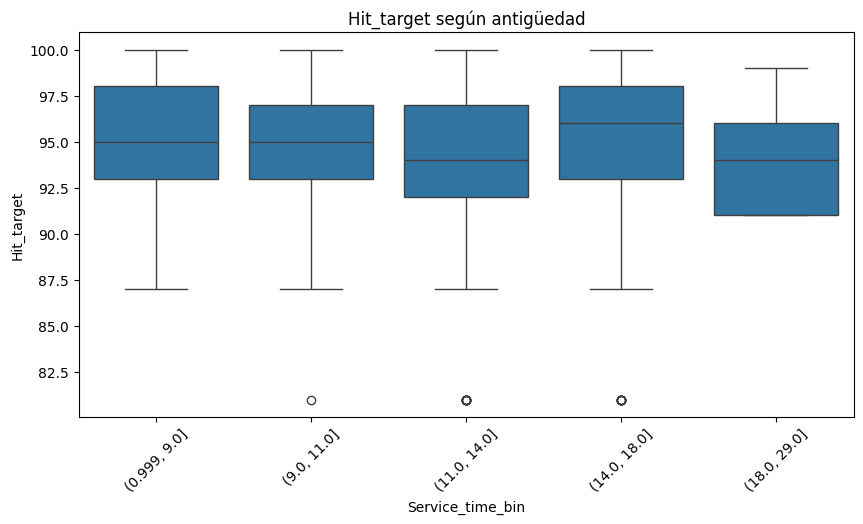

In [ ]:
RRHH['Service_time_bin'] = pd.qcut(RRHH['Service_time'], 5)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=RRHH,
    x='Service_time_bin',
    y='Hit_target'
)

plt.xticks(rotation=45)
plt.title('Hit_target según antigüedad')
plt.show()

### 8.2 Distancia vs Hit target

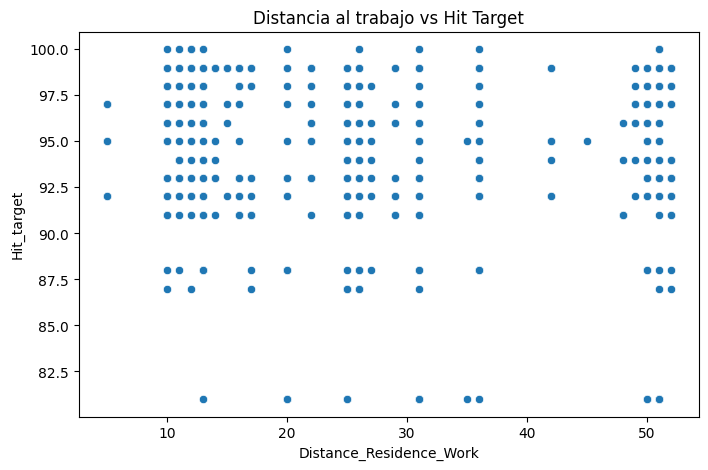

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=RRHH,
    x='Distance_Residence_Work',
    y='Hit_target'
)

plt.title('Distancia al trabajo vs Hit Target')
plt.show()

### 8.3 Work load vs Hit_Target

In [82]:
RRHH['Work_load_Average_day'] = (
    RRHH['Work_load_Average_day']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

RRHH['Work_load_Average_day'] = pd.to_numeric(
    RRHH['Work_load_Average_day'],
    errors='coerce'
)

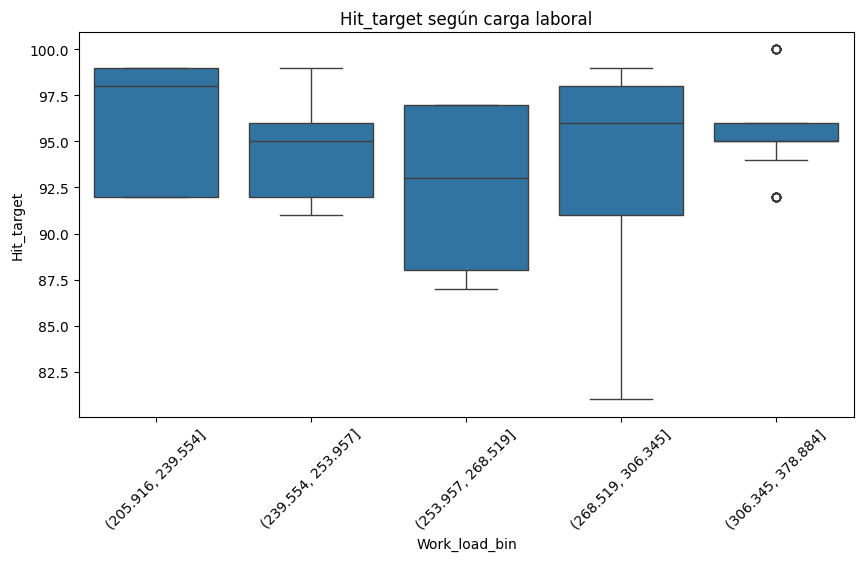

In [85]:
RRHH['Work_load_bin'] = pd.qcut(RRHH['Work_load_Average_day'], 5)
plt.figure(figsize=(10,5))

sns.boxplot(
    data=RRHH,
    x='Work_load_bin',
    y='Hit_target'
)

plt.xticks(rotation=45)
plt.title('Hit_target según carga laboral')
plt.show()

### 8.4 Distancia vs Hit_target

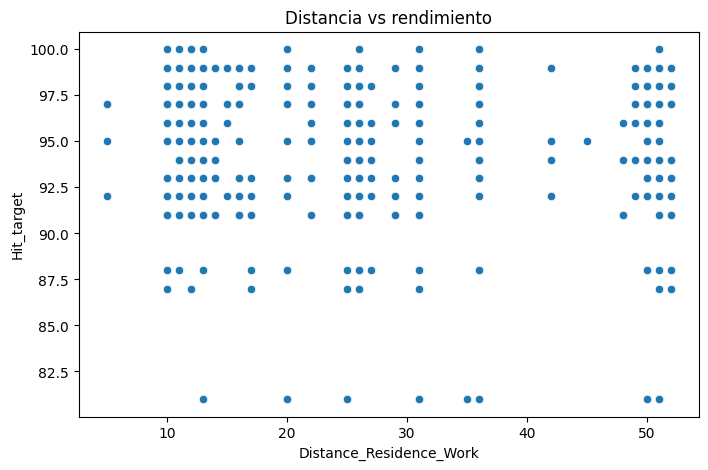

In [86]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=RRHH,
    x='Distance_Residence_Work',
    y='Hit_target'
)

plt.title('Distancia vs rendimiento')
plt.show()

### Percentiles

In [ ]:
RRHH['performance_level'] = pd.qcut(RRHH['Hit_target'], 3, labels=['Bajo', 'Medio', 'Alto'])

RRHH.groupby('performance_level')[[
    'Service_time',
    'Work_load_Average_day',
    'Distance_Residence_Work'
]].mean().round(2)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_463/1530237667.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  RRHH.groupby('performance_level')[[


,Service_time,Work_load_Average_day,Distance_Residence_Work
performance_level,,,
Bajo,12.33,264.49,29.51
Medio,12.85,289.41,30.78
Alto,12.47,255.42,28.07


### Pregunta negocio de Absentismo

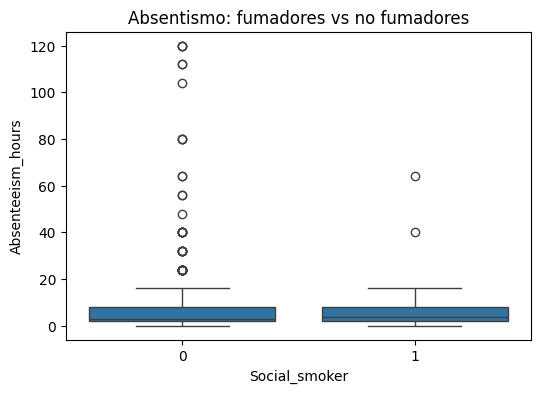

In [91]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Social_smoker',
    y='Absenteeism_hours'
)

plt.title('Absentismo: fumadores vs no fumadores')
plt.show()

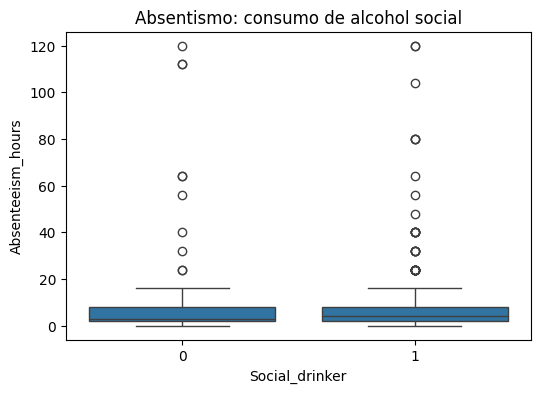

In [92]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Social_drinker',
    y='Absenteeism_hours'
)

plt.title('Absentismo: consumo de alcohol social')
plt.show()

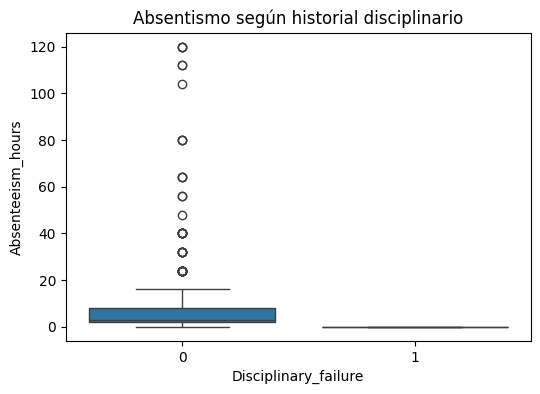

In [93]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=RRHH,
    x='Disciplinary_failure',
    y='Absenteeism_hours'
)

plt.title('Absentismo según historial disciplinario')
plt.show()

Cada vez que se registra Disciplinary Failure no se registra hora de ausencia

## 9. Investigación de repetición por ID

Esta sección justifica por qué un mismo `ID` puede aparecer muchas veces. Si cambian meses, días, motivos u horas, las filas pueden representar situaciones distintas.


In [ ]:
resumen_por_id = (
    RRHH
    .groupby("ID")
    .agg(
        total_filas=("ID", "count")
    )
    .sort_values("total_filas", ascending=False)
)

resumen_por_id.head(10)


,total_filas,meses_distintos,dias_distintos,motivos_distintos,estaciones_distintas,horas_totales,horas_distintas
ID,,,,,,,
3,113,12,5,14,4,482,9
28,76,11,5,16,4,347,9
34,55,12,5,14,4,344,10
22,46,11,5,9,4,253,8
20,42,11,5,11,4,306,8
11,40,11,5,11,4,450,10
15,37,12,5,9,4,253,9
36,34,10,5,9,4,311,9
24,30,10,5,11,4,254,9


## 10. Criterios para limpieza

Estos puntos no se resuelven en el EDA, pero sí afectan la interpretación y deben tratarse antes del dashboard final.


In [ ]:
incidencias_limpieza = pd.DataFrame({
    "Incidencia": [
        "Duplicados exactos",
        "Work_load_Average_day como texto",
        "Month_absence = 0",
        "Reason_absence = 0",
        "Absenteeism_hours = 0",
        "Códigos sin diccionario",
        "Variables de perfil que cambian dentro de un mismo ID",
        "Unidad de análisis mixta"
    ],
    "Criterio propuesto": [
        "Revisar si se eliminan las filas repetidas completas sobrantes",
        "Convertir a numérico en limpieza, no en EDA",
        "Investigar si es código especial o dato no informado",
        "No interpretar sin diccionario de motivos",
        "Revisar si representa ausencia cero, registro administrativo o código especial",
        "Documentar equivalencias de Reason_absence, Day_week, Seasons y Education",
        "Revisar el ID 29 porque cambian edad, educación, distancia, peso, altura y BMI",
        "Separar análisis por registro y por empleado"
    ]
})

incidencias_limpieza


,Incidencia,Criterio propuesto
0,Duplicados exactos,Revisar si se eliminan las filas repetidas com...
1,Work_load_Average_day como texto,"Convertir a numérico en limpieza, no en EDA"
2,Month_absence = 0,Investigar si es código especial o dato no inf...
3,Reason_absence = 0,No interpretar sin diccionario de motivos
4,Absenteeism_hours = 0,"Revisar si representa ausencia cero, registro ..."
5,Códigos sin diccionario,"Documentar equivalencias de Reason_absence, Da..."
6,Variables de perfil que cambian dentro de un m...,"Revisar el ID 29 porque cambian edad, educació..."
7,Unidad de análisis mixta,Separar análisis por registro y por empleado


## 11. Hallazgos y conclusión final

- El dataset tiene 740 registros y 36 IDs únicos.
- La unidad de análisis parece ser un registro de seguimiento de RRHH asociado a Ausencias/ falta disciplinarias de un empleado.
- No hay nulos ni vacíos detectados, pero sí valores especiales que requieren diccionario.
- Las tablas auxiliares de códigos permiten interpretar variables como motivo de ausencia, día de semana, estación y educación sin modificar el dataset original.
- Hay 34 duplicados exactos extra, 60 filas involucradas en duplicados exactos, 26 grupos de filas repetidas y 9 IDs afectados por duplicados exactos.
- La repetición de `ID` no implica automáticamente duplicidad: muchos registros cambian por mes, día, motivo u horas.
- La mayoría de variables de perfil se mantienen constantes por empleado, pero el `ID 29` presenta cambios en variables como edad, educación, distancia, peso, altura y BMI.
- `Work_load_Average_day` debe tratarse en limpieza porque está almacenada como texto.
- Para el dashboard, conviene separar análisis por registro, para temporalidad y motivos, y análisis por empleado, para perfil/desempeño.
